# Hello, KAN!

### Kolmogorov-Arnold representation theorem

Kolmogorov-Arnold representation theorem states that if $f$ is a multivariate continuous function
on a bounded domain, then it can be written as a finite composition of continuous functions of a
single variable and the binary operation of addition. More specifically, for a smooth $f : [0,1]^n \to \mathbb{R}$,


$$f(x) = f(x_1,...,x_n)=\sum_{q=1}^{2n+1}\Phi_q(\sum_{p=1}^n \phi_{q,p}(x_p))$$

where $\phi_{q,p}:[0,1]\to\mathbb{R}$ and $\Phi_q:\mathbb{R}\to\mathbb{R}$. In a sense, they showed that the only true multivariate function is addition, since every other function can be written using univariate functions and sum. However, this 2-Layer width-$(2n+1)$ Kolmogorov-Arnold representation may not be smooth due to its limited expressive power. We augment its expressive power by generalizing it to arbitrary depths and widths.

### Kolmogorov-Arnold Network (KAN)

The Kolmogorov-Arnold representation can be written in matrix form

$$f(x)={\bf \Phi}_{\rm out}\circ{\bf \Phi}_{\rm in}\circ {\bf x}$$

where 

$${\bf \Phi}_{\rm in}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n}(\cdot) \\ \vdots & & \vdots \\ \phi_{2n+1,1}(\cdot) & \cdots & \phi_{2n+1,n}(\cdot) \end{pmatrix},\quad {\bf \Phi}_{\rm out}=\begin{pmatrix} \Phi_1(\cdot) & \cdots & \Phi_{2n+1}(\cdot)\end{pmatrix}$$

We notice that both ${\bf \Phi}_{\rm in}$ and ${\bf \Phi}_{\rm out}$ are special cases of the following function matrix ${\bf \Phi}$ (with $n_{\rm in}$ inputs, and $n_{\rm out}$ outputs), we call a Kolmogorov-Arnold layer:

$${\bf \Phi}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n_{\rm in}}(\cdot) \\ \vdots & & \vdots \\ \phi_{n_{\rm out},1}(\cdot) & \cdots & \phi_{n_{\rm out},n_{\rm in}}(\cdot) \end{pmatrix}$$

${\bf \Phi}_{\rm in}$ corresponds to $n_{\rm in}=n, n_{\rm out}=2n+1$, and ${\bf \Phi}_{\rm out}$ corresponds to $n_{\rm in}=2n+1, n_{\rm out}=1$.

After defining the layer, we can construct a Kolmogorov-Arnold network simply by stacking layers! Let's say we have $L$ layers, with the $l^{\rm th}$ layer ${\bf \Phi}_l$ have shape $(n_{l+1}, n_{l})$. Then the whole network is

$${\rm KAN}({\bf x})={\bf \Phi}_{L-1}\circ\cdots \circ{\bf \Phi}_1\circ{\bf \Phi}_0\circ {\bf x}$$

In constrast, a Multi-Layer Perceptron is interleaved by linear layers ${\bf W}_l$ and nonlinearities $\sigma$:

$${\rm MLP}({\bf x})={\bf W}_{L-1}\circ\sigma\circ\cdots\circ {\bf W}_1\circ\sigma\circ {\bf W}_0\circ {\bf x}$$

A KAN can be easily visualized. (1) A KAN is simply stack of KAN layers. (2) Each KAN layer can be visualized as a fully-connected layer, with a 1D function placed on each edge. Let's see an example below.

Initialize KAN

In [61]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[34,4,1], grid=3, k=3, seed=42, device=device)

cuda
checkpoint directory created: ./model
saving model version 0.0


Create dataset

In [62]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split

# ---------- 1. 基本设置 ----------
torch.set_default_dtype(torch.float64)

csv_path = "0-MY-DATASET-RR.csv"   # 确保路径正确（与你的 notebook 同级）

# ---------- 2. 读取 CSV ----------
df = pd.read_csv(csv_path)

print("Raw data shape:", df.shape)
print("Columns:", df.columns.tolist())

# ---------- 3. 拆分特征与标签 ----------
# 前 34 列：特征
X = df.iloc[:, 0:34].apply(pd.to_numeric, errors='coerce')

# 第 35 列：信任度等级标签 (1/2/3)
y = pd.to_numeric(df.iloc[:, 34], errors='coerce')

# ---------- 4. 数据清洗 ----------
# 去掉含 NaN 的样本
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

# 只保留合法标签 1/2/3
valid_mask = y.isin([1, 2, 3])
X = X[valid_mask]
y = y[valid_mask]

print("Cleaned samples:", len(y))

# ---------- 5. numpy 化 ----------
X = X.to_numpy(dtype=np.float64)
y = y.to_numpy(dtype=np.float64)

# ---------- 6. 训练 / 测试集划分 ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y   # 保持 1/2/3 比例一致（非常重要）
)

print("Train samples:", X_train.shape[0])
print("Test samples :", X_test.shape[0])

# ---------- 7. 特征标准化（强烈建议） ----------
# ⚠️ 只用训练集统计量，防止信息泄露
mean = X_train.mean(axis=0, keepdims=True)
std  = X_train.std(axis=0, keepdims=True) + 1e-12

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

# ---------- 8. 转为 torch Tensor ----------
X_train_t = torch.tensor(X_train, device=device)
X_test_t  = torch.tensor(X_test,  device=device)

# KAN 输出推荐使用 (N, 1)
y_train_t = torch.tensor(y_train, device=device).reshape(-1, 1)
y_test_t  = torch.tensor(y_test,  device=device).reshape(-1, 1)

# ---------- 9. 组装成 KAN 标准 dataset ----------
dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input':  X_test_t,
    'test_label':  y_test_t
}

# ---------- 10. sanity check ----------
print("dataset['train_input']:", dataset['train_input'].shape)
print("dataset['train_label']:", dataset['train_label'].shape)
#print("Unique labels in train:", torch.unique(dataset['train_label']))

def to_cpu_dataset(dataset):
    return {
        'train_input': dataset['train_input'].detach().cpu().double(),
        'train_label': dataset['train_label'].detach().cpu().double(),
        'test_input' : dataset['test_input'].detach().cpu().double(),
        'test_label' : dataset['test_label'].detach().cpu().double(),
    }

dataset_cpu = to_cpu_dataset(dataset)


Raw data shape: (10185, 35)
Columns: ['ECG_Max', 'ECG_SD', 'alpha_psd', 'ECG_Mean', 'ECG_Q1', 'delta_amp', 'ECG_Q2', 'ECG_Q3', 'beta_amp', 'ECG_AVHR', 'ECG_IBI', 'theta_psd', 'ECG_RMSSD', 'time_std', 'theta_amp', 'ECG_pNN20', 'ECG_pNN50', 'beta_psd', 'EDA_SC', 'EDA_SCL', 'alpha_amp', 'EDA_SCR', 'EDA_Max', 'EDA_SD', 'delta_psd', 'EDA_Mean', 'EDA_Q1', 'EDA_Q2', 'EDA_Q3', 'time_mean', 'time_max', 'time_min', 'time_skew', 'time_kurtosis', 'trust level']
Cleaned samples: 10143
Train samples: 8114
Test samples : 2029
dataset['train_input']: torch.Size([8114, 34])
dataset['train_label']: torch.Size([8114, 1])


In [63]:
import copy
import torch

def cpu_grid_update_once(model, dataset_cpu,
                         opt="LBFGS",
                         steps=5,
                         lamb=0.001,
                         grid_update_num=1,
                         start_grid_update_step=0,
                         stop_grid_update_step=5,
                         verbose=1):
    """
    在 CPU 上短跑几步 + update_grid=True，让 grid/coef 更新完成。
    返回搬回 GPU 的 model（参数已更新）。
    """
    # 1) 深拷贝到 CPU，避免影响你 GPU 上的对象引用
    model_cpu = copy.deepcopy(model).to("cpu").double()

    # 2) CPU 上做 grid update（短跑）
    model_cpu.fit(
        dataset_cpu,
        opt=opt,
        steps=steps,
        lamb=lamb,
        update_grid=True,
        grid_update_num=grid_update_num,
        start_grid_update_step=start_grid_update_step,
        stop_grid_update_step=stop_grid_update_step,
    )

    # 3) 搬回原 device（cuda）
    model_gpu = model_cpu.to(model.device)
    return model_gpu

Plot KAN at initialization

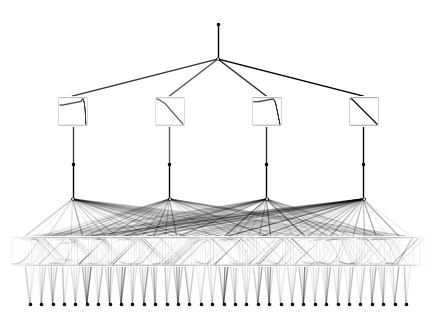

In [64]:
# plot KAN at initialization
model(dataset['train_input']);
model.plot(beta=3, scale=0.5)

Train KAN with sparsity regularization

In [67]:
# 进行一次 CPU grid update（只更新grid，不追求收敛）
model = cpu_grid_update_once(
    model,
    dataset_cpu,
    opt="LBFGS",
    steps=5,
    lamb=0.001,
    grid_update_num=1,
    start_grid_update_step=0,
    stop_grid_update_step=5,
)

# 回到 GPU 再训练
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, update_grid=False)

RuntimeError: Only Tensors created explicitly by the user (graph leaves) support the deepcopy protocol at the moment.  If you were attempting to deepcopy a module, this may be because of a torch.nn.utils.weight_norm usage, see https://github.com/pytorch/pytorch/pull/103001

In [ ]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001)

# train the model
# model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001);

In [41]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")


Test Classification Accuracy: 80.63%


Plot trained KAN

In [60]:
model.plot(beta=3, scale=0.5)

# plt.savefig("KAN_structure.svg", bbox_inches="tight")

Exception: model hasn't seen any data yet.

In [ ]:
import torch
import numpy as np

def _get_plot_scores(model, metric: str):
    if metric == "forward_n":
        return model.acts_scale
    elif metric == "forward_u":
        return model.edge_actscale
    elif metric == "backward":
        return model.edge_scores
    else:
        raise ValueError(f"metric='{metric}' not recognized (use 'backward'/'forward_n'/'forward_u')")

@torch.no_grad()
def _get_alpha_mask(model, l: int, i: int, j: int) -> float:
    """
    严格复刻 plot() 里的 alpha_mask 逻辑：
      symbolic_mask = self.symbolic_fun[l].mask[j][i]
      numeric_mask  = self.act_fun[l].mask[i][j]
      只有两者都为0时 alpha_mask=0，否则为1
    """
    symbolic_mask = float(model.symbolic_fun[l].mask[j][i])
    numeric_mask  = float(model.act_fun[l].mask[i][j])
    if symbolic_mask == 0.0 and numeric_mask == 0.0:
        return 0.0
    return 1.0

@torch.no_grad()
def print_top_bottom_edges_like_plot(model, beta=3, metric="backward", topk=10, bottomk=10, include_pruned=False):
    """
    打印与 model.plot() “线条粗细/透明度”严格一致的 Top/Bottom 边：
    - 排序依据：plot 使用的 scores（edge_scores/acts_scale/edge_actscale）
    - mask处理：与 plot 一致：alpha * alpha_mask；被剪掉的边 alpha_mask=0（默认不参与排序）
    """
    scores = _get_plot_scores(model, metric)  # list: scores[l] shape [out, in]
    depth = len(model.width) - 1

    edges = []
    for l in range(depth):
        s = scores[l].detach().cpu().double()  # (out, in)
        out_dim, in_dim = s.shape[0], s.shape[1]
        for j in range(out_dim):
            for i in range(in_dim):
                alpha_mask = _get_alpha_mask(model, l, i, j)  # 注意 plot 的索引顺序：symbolic mask[j][i], numeric mask[i][j]
                alpha = float(np.tanh(beta * float(s[j, i])))
                alpha_eff = alpha * alpha_mask  # plot 真实用到的透明度
                if (not include_pruned) and alpha_mask == 0.0:
                    continue
                edges.append((alpha_eff, float(s[j, i]), alpha_mask, l, i, j))

    # 按“最终用于画线的透明度 alpha_eff”排序，严格对应粗细/深浅
    edges.sort(key=lambda t: t[0], reverse=True)

    def fmt(e):
        alpha_eff, score, alpha_mask, l, i, j = e
        return f"(L{l} i{i}->o{j}) score={score:.6g} alpha=tanh({beta}*score)={np.tanh(beta*score):.6g} alpha_mask={alpha_mask:.0f} alpha_eff={alpha_eff:.6g}"

    print(f"\n[Plot-aligned ranking] metric='{metric}', beta={beta}")
    print(f"Total counted edges = {len(edges)} (include_pruned={include_pruned})")

    print(f"\nTop-{topk} edges (most visible/thick in plot):")
    for k in range(min(topk, len(edges))):
        print(f"  #{k+1:02d}  {fmt(edges[k])}")

    print(f"\nBottom-{bottomk} edges (least visible in plot):")
    for k in range(min(bottomk, len(edges))):
        print(f"  #{k+1:02d}  {fmt(edges[-1-k])}")

def plot_with_aligned_top_bottom(model, beta=3, metric="backward", scale=0.5, topk=10, bottomk=10, include_pruned=False, **plot_kwargs):
    """
    一条命令：先 plot（确保 edge_scores 等已准备好），再打印与 plot 完全一致的 Top/Bottom。
    """
    # plot(metric='backward') 内部会 attribute()，从而更新 edge_scores
    model.plot(beta=beta, metric=metric, scale=scale, **plot_kwargs)
    print_top_bottom_edges_like_plot(
        model, beta=beta, metric=metric,
        topk=topk, bottomk=bottomk,
        include_pruned=include_pruned
    )


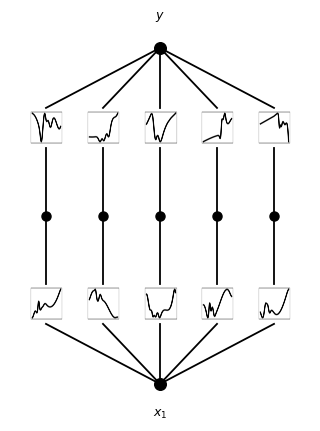

In [33]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def redraw_single_io_path_parallel(
    folder="./figures",
    i_in=2,                 # x3 -> 2
    j_out=0,                # 单输出 -> 0
    H=5,                    # 5 条并行通道
    in_label=r"$x_3$",
    out_label=r"$y$",
    scale=1.2,
    fig_w=6.0,
    fig_h=8.0,
    # 版式参数（可微调）
    x_margin=0.12,          # 左右留白
    y_in=0.08,              # x3 点的 y
    y_row0=0.28,            # 第一层小图中心 y
    y_hidden=0.50,          # 隐层圆点 y
    y_row1=0.72,            # 第二层小图中心 y
    y_out=0.92,             # y 点的 y
    img_w=0.12,             # 小图宽（归一化坐标）
    img_h=0.10,             # 小图高（归一化坐标）
    lw=2.6,                 # 连线粗细
    dot_in_size=140,
    dot_h_size=85,
    dot_out_size=140,
    savepath=None
):
    """
    需要文件（与 KAN/MultKAN plot 保存一致）：
      layer0: sp_0_{i_in}_{h}.png , h=0..H-1
      layer1: sp_1_{h}_{j_out}.png , h=0..H-1
    """

    # ====== 画布 ======
    fig = plt.figure(figsize=(fig_w*scale, fig_h*scale))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # ====== 横向位置：5 个通道居中排布 ======
    xs = np.linspace(x_margin, 1 - x_margin, H)

    # ====== 节点坐标 ======
    x_in,  y_in_  = 0.5, y_in
    x_out, y_out_ = 0.5, y_out

    # ====== 画输入/输出圆点 + 标签（居中） ======
    ax.scatter([x_in], [y_in_], s=dot_in_size*scale, c="k", zorder=10)
    ax.text(x_in, y_in_ - 0.06, in_label, ha="center", va="top",
            fontsize=18*scale)

    ax.scatter([x_out], [y_out_], s=dot_out_size*scale, c="k", zorder=10)
    ax.text(x_out, y_out_ + 0.06, out_label, ha="center", va="bottom",
            fontsize=18*scale)

    # ====== 画隐层 5 个圆点 ======
    ax.scatter(xs, [y_hidden]*H, s=dot_h_size*scale, c="k", zorder=10)

    # ====== 工具：在指定中心点贴一张 png 小图 ======
    def place_png(center_x, center_y, png_path, w=img_w, h=img_h):
        left = center_x - w/2
        bottom = center_y - h/2
        if os.path.exists(png_path):
            im = mpimg.imread(png_path)
            ax_img = fig.add_axes([left, bottom, w, h])
            ax_img.imshow(im)
            ax_img.axis("off")
            ax_img.patch.set_alpha(0.0)
        else:
            # 找不到就画红框提示
            rect = plt.Rectangle((left, bottom), w, h, fill=False, lw=1.5, ec="r")
            ax.add_patch(rect)

    # ====== 每个通道：x3 -> 第一层小图 -> 隐层点 -> 第二层小图 -> y ======
    for h in range(H):
        xh = xs[h]

        # 第一层小图（sp_0_{i_in}_{h}）
        p0 = os.path.join(folder, f"sp_0_{i_in}_{h}.png")
        place_png(xh, y_row0, p0)

        # 第二层小图（sp_1_{h}_{j_out}）
        p1 = os.path.join(folder, f"sp_1_{h}_{j_out}.png")
        place_png(xh, y_row1, p1)

        # 关键：连线结构要像你的手绘——每条通道基本竖直（只在最底/最顶扇出）
        # 1) x3 -> 第一层小图（连到小图下边缘中心）
        ax.plot([x_in, xh],
                [y_in_, y_row0 - img_h/2],
                c="k", lw=lw*scale, zorder=2)

        # 2) 第一层小图上边缘中心 -> 隐层点（竖直）
        ax.plot([xh, xh],
                [y_row0 + img_h/2, y_hidden],
                c="k", lw=lw*scale, zorder=2)

        # 3) 隐层点 -> 第二层小图下边缘中心（竖直）
        ax.plot([xh, xh],
                [y_hidden, y_row1 - img_h/2],
                c="k", lw=lw*scale, zorder=2)

        # 4) 第二层小图上边缘中心 -> y（扇出到顶点）
        ax.plot([xh, x_out],
                [y_row1 + img_h/2, y_out_],
                c="k", lw=lw*scale, zorder=2)

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()


# ====== 用法示例：只画 x3 (i_in=2) 到 y (j_out=0)，H=5 ======
redraw_single_io_path_parallel(
    folder="./figures",
    i_in=0,
    j_out=0,
    H=5,
    in_label=r"$x_1$",
    out_label=r"$y$",
    scale=0.5,
    savepath=None  # 例如 "single_path_x3_to_y.png"
    # savepath="x1_to_y.svg"
)


Prune KAN and replot

saving model version 0.2


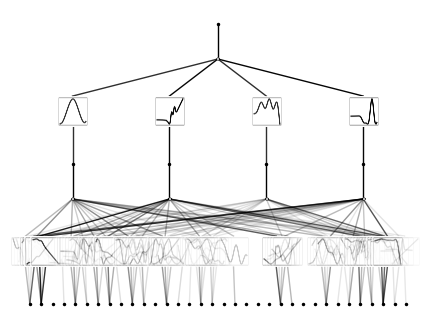

In [5]:
model = model.prune()
model.plot()

Continue training and replot

In [ ]:
model.fit(dataset, opt="LBFGS", steps=50, update_grid=False);

| train_loss: 3.91e-01 | test_loss: 4.05e-01 | reg: 3.22e+01 | : 100%|█| 50/50 [00:39<00:00,  1.28it

saving model version 0.3


In [43]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")

Test Classification Accuracy: 79.84%


In [10]:
model = model.refine(10)

saving model version 0.4


In [ ]:
model.fit(dataset, opt="LBFGS", steps=50, update_grid=False);

| train_loss: 4.01e-01 | test_loss: 4.31e-01 | reg: 2.76e+02 | : 100%|█| 50/50 [01:20<00:00,  1.61s/

saving model version 0.5


In [12]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")

Test Classification Accuracy: 78.17%


Automatically or manually set activation functions to be symbolic

In [121]:
mode = "auto" # "manual"

if mode == "manual":
    # manual mode
    model.fix_symbolic(0,0,0,'sin');
    model.fix_symbolic(0,1,0,'x^2');
    model.fix_symbolic(1,0,0,'exp');
elif mode == "auto":
    # automatic mode
    # lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
    lib = ['x','x^2','x^3','x^4','abs','tanh','sin']
    model.auto_symbolic(lib=lib, r2_threshold=0.999)

For (0,0,0) the best fit was x, but r^2 = 0.06346124707803256 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,0,1) the best fit was x, but r^2 = 0.0863023554795215 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,0,2) the best fit was x, but r^2 = 0.9539781905903676 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,0,3) the best fit was x, but r^2 = 0.6153211008536943 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,0,4) the best fit was x, but r^2 = 0.05863499789733226 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,1,0) the best fit was x, but r^2 = 0.966143170985466 and this is lower than 0.999. This edge was omitted, keep training or try a different threshold.
For (0,1,1) the best fit was x, but r^2 = 0.7930320

Continue training till machine precision

In [ ]:
model.fit(dataset, opt="LBFGS", steps=50, lamb=0.001, update_grid=False);


| train_loss: 4.75e-01 | test_loss: 4.86e-01 | reg: 2.01e+01 | : 100%|█| 50/50 [00:10<00:00,  4.70it

saving model version 0.4


In [123]:
# ================================
# Classification accuracy (3-class)
# ================================

import torch

model.eval()
with torch.no_grad():
    # 连续预测
    y_pred_cont = model(dataset['test_input'])  # (N, 1)

    # 映射到 1 / 2 / 3
    y_pred_cls = torch.round(y_pred_cont)
    y_pred_cls = torch.clamp(y_pred_cls, 1, 3)

    # 真实标签
    y_true = dataset['test_label']

    # 准确率
    accuracy = (y_pred_cls == y_true).float().mean()

print(f"Test Classification Accuracy: {accuracy.item() * 100:.2f}%")

Test Classification Accuracy: 72.55%


Obtain the symbolic formula

In [1]:
from kan.utils import ex_round

ex_round(model.symbolic_formula()[0][0],4)

NameError: name 'model' is not defined